In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
H_Prices = pd.read_csv('bengaluru_house_prices.csv')

In [4]:
H_Prices.sample(20)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
8681,Super built-up Area,17-Apr,Chikkalasandra,2 BHK,NaN,1070,2.0,1.0,45.48
9912,Super built-up Area,Ready To Move,Hosakerehalli,3 BHK,Taonte,2378,3.0,1.0,310.00
519,Built-up Area,Ready To Move,Hosur Road,3 BHK,NaN,1175,2.0,2.0,48.00
2061,Super built-up Area,20-Dec,Jakkur,2 BHK,ArndsSk,1100,2.0,1.0,53.35
5475,Super built-up Area,21-Dec,Kanakpura Road,2 BHK,PrarePa,900,2.0,1.0,41.00
5384,Super built-up Area,Ready To Move,Yeshwanthpur,1 BHK,IBityin,670,1.0,1.0,36.85
5726,Super built-up Area,Ready To Move,Electronics City Phase 1,3 BHK,NianaBr,1291,2.0,3.0,32.00
9000,Super built-up Area,Ready To Move,Kenchenahalli,1 BHK,AriosPa,700,1.0,1.0,35.00
2098,Super built-up Area,18-Apr,Electronic City Phase II,2 BHK,MJtroty,1003,2.0,1.0,40.60
8314,Plot Area,Ready To Move,Gattigere,5 Bedroom,NaN,900,6.0,1.0,95.00


In [5]:
H_Prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
H_Prices.describe()


,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [13]:
H_Prices.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [44]:
H_Prices['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [45]:
H_Prices['area_type'].unique()

array(['Super built-up  Area', 'Plot  Area', 'Built-up  Area',
       'Carpet  Area'], dtype=object)

In [77]:
H_Prices['price'].skew()

np.float64(8.069783326007764)

In [78]:
H_Prices['Size_Bed'].skew()

np.float64(4.822008589271808)

<Axes: >

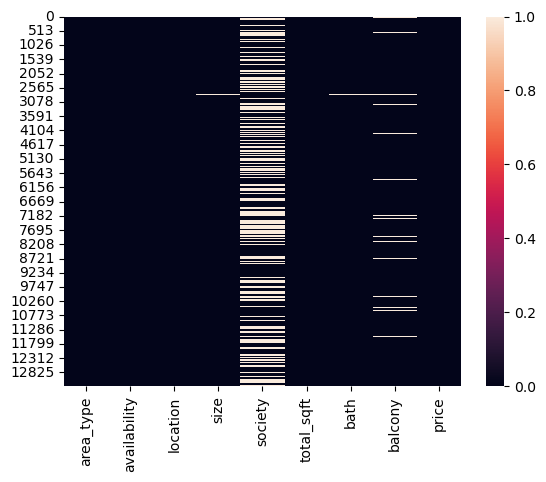

In [16]:
sns.heatmap(H_Prices.isnull(),cbar= True) #Just a visual representation of missing values

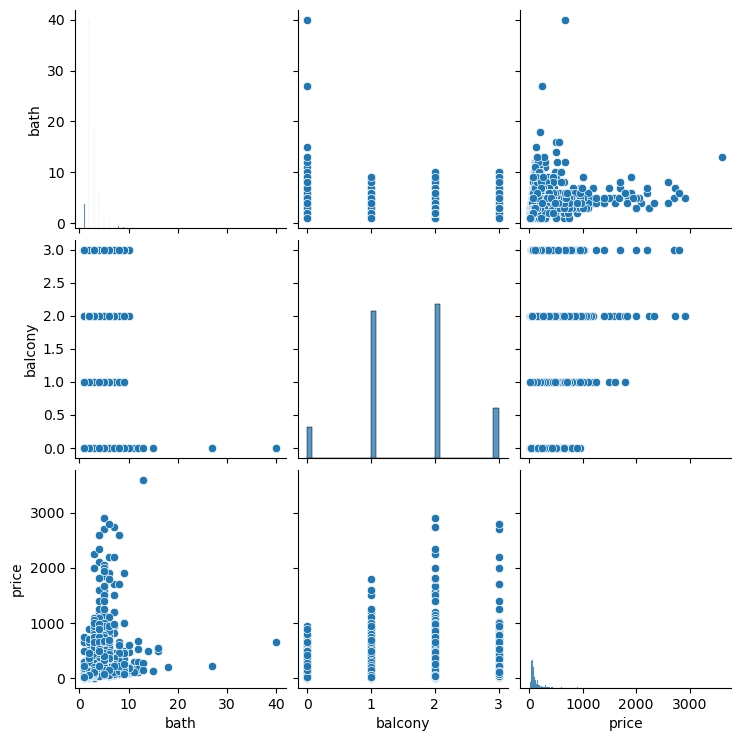

In [10]:
sns.pairplot(H_Prices)

OBSERVATIONS:

1. Missing values to handle
2. Convert total_sqrt to float
3. Extract the first number of size to get the number of bedrooms. Use a function

In [ ]:
#Convert character to float

In [20]:
H_Prices['total_sqft'] = pd.to_numeric(H_Prices['total_sqft'], errors='coerce')

In [22]:
H_Prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13073 non-null  float64
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(4), object(5)
memory usage: 936.7+ KB


In [ ]:
# Now we are getting Number of bedrooms and making it numeric

In [32]:
def N_bed(x):
    if pd.isna(x):
        return None
    return x.split()[0]

H_Prices['Size_Bed'] = pd.to_numeric(H_Prices['size'].apply(N_bed),errors = 'coerce')

In [33]:
H_Prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13073 non-null  float64
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
 9   Size_Bed      13304 non-null  float64
dtypes: float64(5), object(5)
memory usage: 1.0+ MB


In [72]:
#From observation, it looks like there are oulies in total_sqft. 0th percentile and 25th percentile have significant difference, same as 75th and 100th percentile

In [34]:
H_Prices.describe()

,total_sqft,bath,balcony,price,Size_Bed
count,13073.000000,13247.000000,12711.000000,13320.000000,13304.000000
mean,1554.942029,2.692610,1.584376,112.565627,2.803743
std,1238.458773,1.341458,0.817263,148.971674,1.294974
min,1.000000,1.000000,0.000000,8.000000,1.000000
25%,1100.000000,2.000000,1.000000,50.000000,2.000000
50%,1275.000000,2.000000,2.000000,72.000000,3.000000
75%,1670.000000,3.000000,2.000000,120.000000,3.000000
max,52272.000000,40.000000,3.000000,3600.000000,43.000000


Let's explore the data! EDA!!!

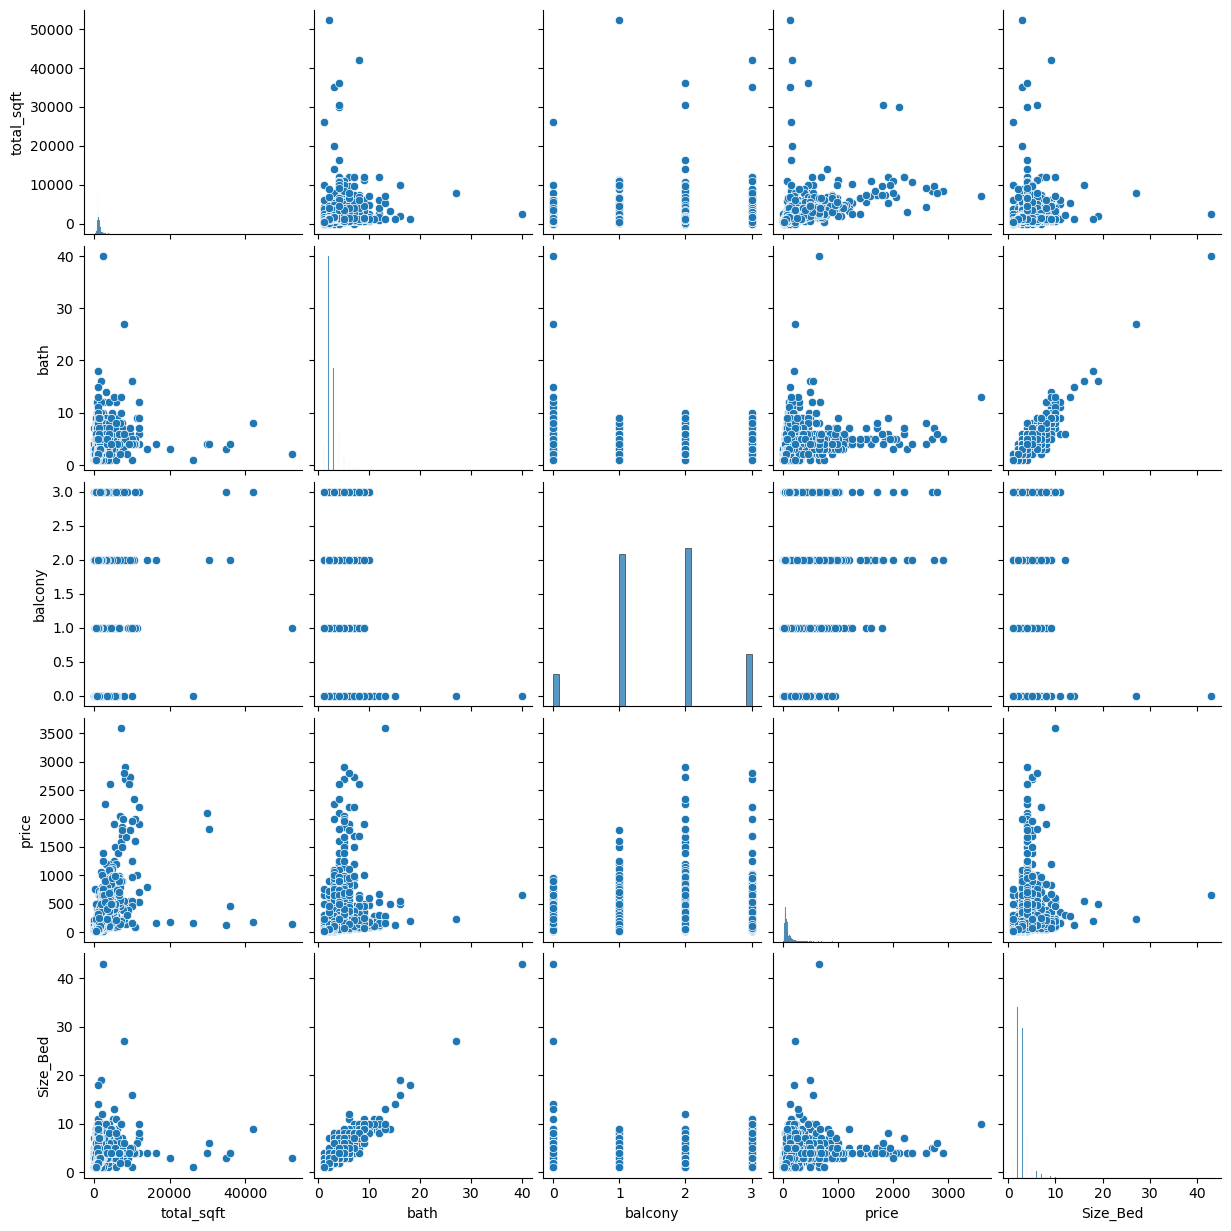

In [36]:
sns.pairplot(H_Prices)

<Axes: xlabel='Size_Bed', ylabel='Count'>

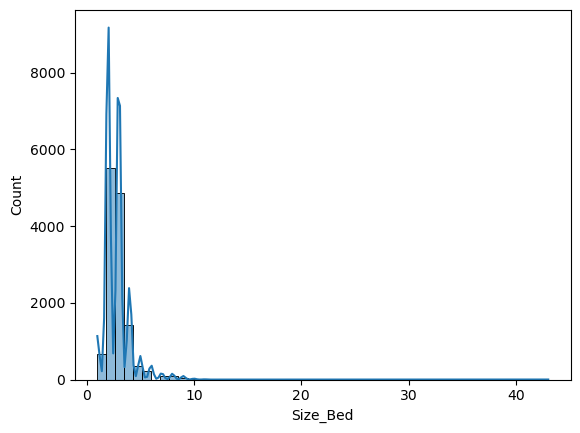

In [75]:
sns.histplot(H_Prices['Size_Bed'],bins=50,kde=True)

<Axes: xlabel='price', ylabel='Count'>

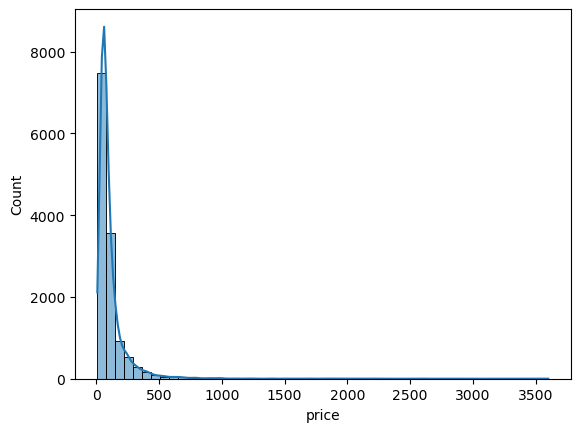

In [74]:
sns.histplot(H_Prices['price'],bins=50, kde=True)

<Axes: xlabel='balcony', ylabel='Count'>

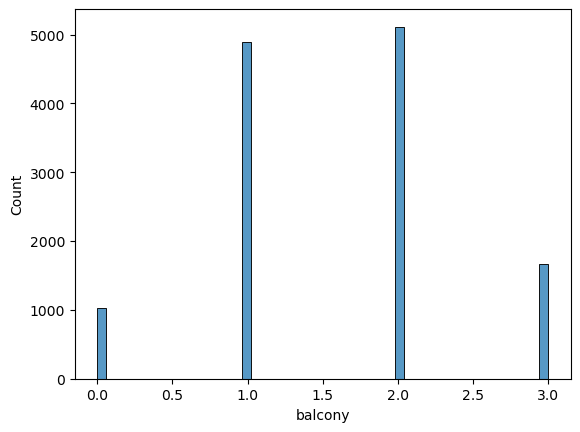

In [50]:
sns.histplot(H_Prices['balcony'],bins=50)

<Axes: xlabel='total_sqft', ylabel='Count'>

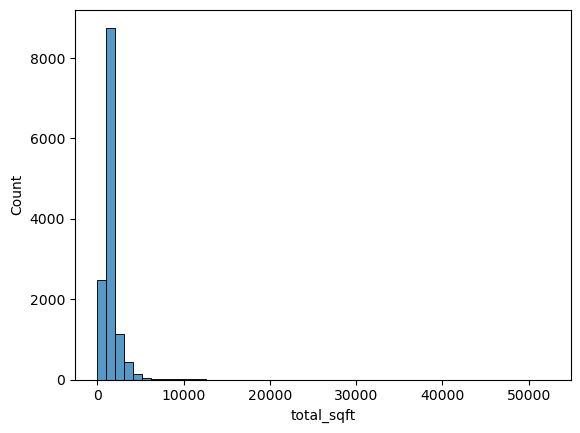

In [52]:
sns.histplot(H_Prices['total_sqft'],bins=50)

Now lets fix the missing values

<Axes: >

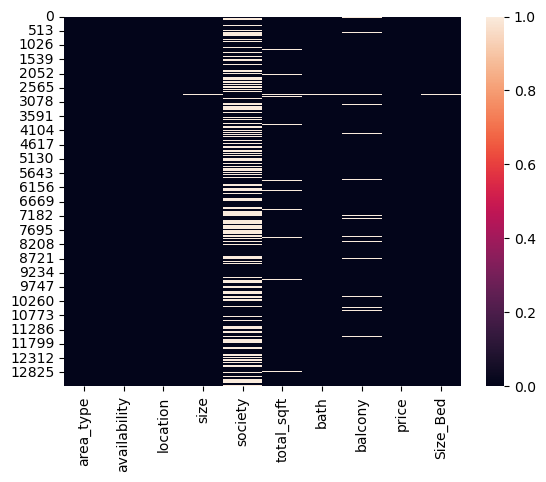

In [53]:
sns.heatmap(H_Prices.isnull(),cbar= True) #Just a visual representation of missing values

In [54]:
#for total_sqrf, balcony and size_bedroom I will take the mean to replace the missing value


In [58]:
H_Prices.dropna(subset ='Size_Bed', inplace = True)

In [62]:
H_Prices['balcony'].fillna(value = 2, inplace = True)

/var/folders/5_/s1zmq48x46gcq9k6cc3xvplm0000gn/T/ipykernel_48297/1680849920.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  H_Prices['balcony'].fillna(value = 2, inplace = True)


In [64]:
H_Prices['total_sqft'].fillna(value = 1555, inplace = True)

/var/folders/5_/s1zmq48x46gcq9k6cc3xvplm0000gn/T/ipykernel_48297/2089569721.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  H_Prices['total_sqft'].fillna(value = 1555, inplace = True)


In [140]:
H_Prices['bath'].fillna(value = 3, inplace = True)

/var/folders/5_/s1zmq48x46gcq9k6cc3xvplm0000gn/T/ipykernel_48297/1488797511.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  H_Prices['bath'].fillna(value = 3, inplace = True)


<Axes: >

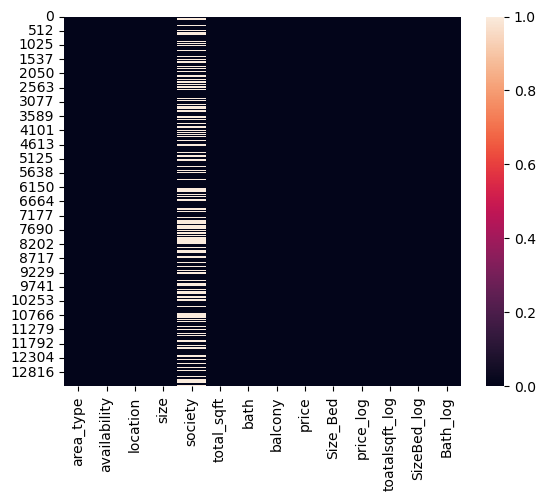

In [141]:
sns.heatmap(H_Prices.isnull(),cbar= True) 

<Axes: xlabel='balcony', ylabel='price'>

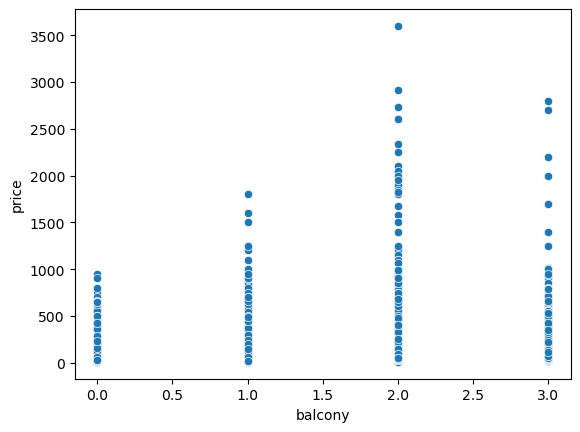

In [142]:
sns.scatterplot(data = H_Prices, x='balcony',y='price')

<Axes: xlabel='Size_Bed', ylabel='price'>

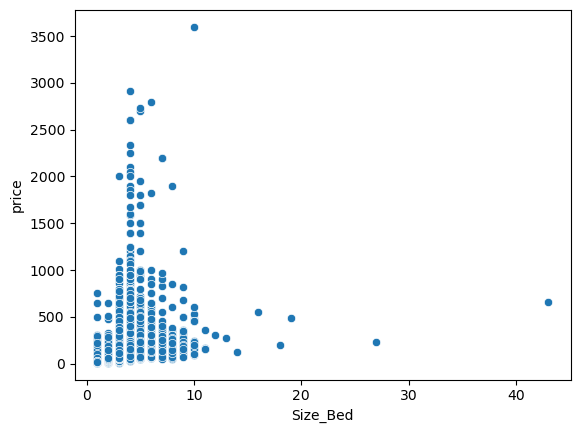

In [143]:
sns.scatterplot(data = H_Prices, x='Size_Bed',y='price')

In [144]:
# from this scatterplot it is evident that we have outlies 

<Axes: xlabel='total_sqft', ylabel='price'>

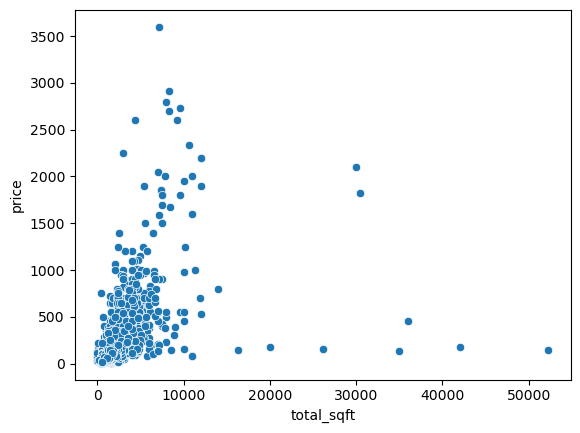

In [145]:
sns.scatterplot(data = H_Prices, x='total_sqft',y='price')

<Axes: xlabel='bath', ylabel='price'>

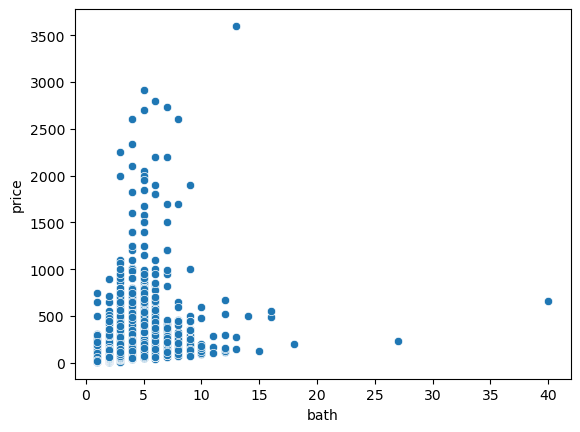

In [146]:
sns.scatterplot(data = H_Prices, x='bath',y='price')

Dealing with Outliers
1.delete outlies
2.Log the right skewed
3. clib when real but too extreme

In [147]:
H_Prices['price_log'] = np.log1p(H_Prices['price']) #log
H_Prices['toatalsqft_log'] = np.log1p(H_Prices['total_sqft'])
H_Prices['SizeBed_log'] = H_Prices['Size_Bed'].clip(1, 43) #clip
H_Prices['Bath_log'] = H_Prices['bath'].clip(1, 40)

In [148]:
H_Prices.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,Size_Bed,price_log,toatalsqft_log,SizeBed_log,Bath_log
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2.0,3.690628,6.963190,2.0,2.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4.0,4.795791,7.863651,4.0,5.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,3.0,62.00,3.0,4.143135,7.273093,3.0,2.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3.0,4.564348,7.327781,3.0,3.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,1.0,51.00,2.0,3.951244,7.090910,2.0,2.0


In [149]:
H_Prices['price_log'].skew()

np.float64(0.8612262893116694)

In [150]:
H_Prices['toatalsqft_log'].skew()

np.float64(0.20100848268451896)

In [151]:
H_Prices['SizeBed_log'].skew()

np.float64(4.822008589271808)

In [152]:
H_Prices.drop(['total_sqft','price','Size_Bed','bath'], axis=1).corr(numeric_only=True)

,balcony,price_log,toatalsqft_log,SizeBed_log,Bath_log
balcony,1.000000,0.207954,0.259278,0.194800,0.210017
price_log,0.207954,1.000000,0.729170,0.569370,0.615623
toatalsqft_log,0.259278,0.729170,1.000000,0.443213,0.493997
SizeBed_log,0.194800,0.569370,0.443213,1.000000,0.897212
Bath_log,0.210017,0.615623,0.493997,0.897212,1.000000


In [153]:
#There is a strong corr between bath and bedroom size. We will keep both the columns for now. 

<Axes: >

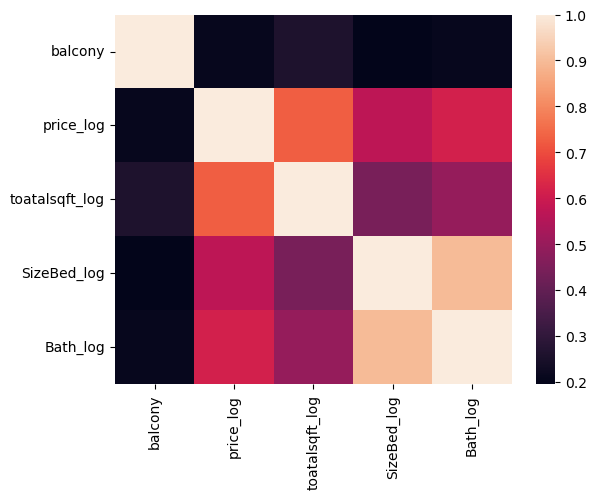

In [154]:
sns.heatmap(H_Prices.drop(['total_sqft','price','Size_Bed','bath'], axis=1).corr(numeric_only=True))

Now lets develop the model 

In [155]:
#Lets define the label and features

In [156]:
H_Prices.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price', 'Size_Bed', 'price_log',
       'toatalsqft_log', 'SizeBed_log', 'Bath_log'],
      dtype='object')

In [157]:
y= H_Prices[['Bath_log','balcony','toatalsqft_log', 'SizeBed_log']]
X= H_Prices[['price_log']]

In [158]:
y.isnull().sum()

Bath_log          0
balcony           0
toatalsqft_log    0
SizeBed_log       0
dtype: int64

In [159]:
from sklearn.model_selection import train_test_split

In [160]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [161]:
from sklearn.linear_model import LinearRegression

In [162]:
ln = LinearRegression()

In [163]:
ln.fit(X_test,y_test)

LinearRegression()

In [169]:
coeficients = pd.DataFrame(ln.coef_,y.columns,columns = ['Coefs'])

In [170]:
coeficients

,Coefs
Bath_log,1.115255
balcony,0.205939
toatalsqft_log,0.446540
SizeBed_log,1.009302


In [171]:
ln.intercept_

array([-2.23350294,  0.68870661,  5.25926976, -1.65992861])

In [172]:
predictions = ln.predict(X_train)